# NASA Climate Pt. 2 (Runnable Environment Version)

This notebook runs an Ornstein-Uhlenbeck workflow and saves reproducible artifacts.

In [1]:
from pathlib import Path
import importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parents[2]
module_path = ROOT / 'articles/nasa-climate-data-pt2-sdes/src/sde_ou.py'
spec = importlib.util.spec_from_file_location('sde_ou', module_path)
sde_ou = importlib.util.module_from_spec(spec)
spec.loader.exec_module(sde_ou)

rng = np.random.default_rng(42)
DELTA_T = 0.01
path = sde_ou.simulate_ou_path(
    initial_value=0.2,
    theta=0.35,
    mu=0.0,
    sigma=0.3,
    delta_t=DELTA_T,
    num_steps=1000,
    random_seed=42,
)
theta_hat = sde_ou.estimate_ou_mean_reversion(path, delta_t=DELTA_T)
print('Estimated mean-reversion speed:', round(theta_hat, 4))


Estimated mean-reversion speed: 0.911


Saved: ../figures/ou_simulated_temperature_anomaly.png


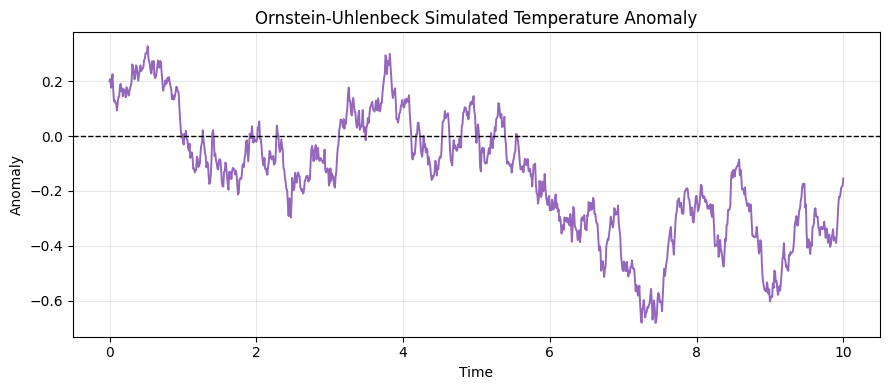

In [2]:
t = np.arange(len(path))*0.01
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(t, path, lw=1.4, color='tab:purple')
ax.axhline(0.0, color='black', ls='--', lw=1)
ax.set_title('Ornstein-Uhlenbeck Simulated Temperature Anomaly')
ax.set_xlabel('Time')
ax.set_ylabel('Anomaly')
ax.grid(alpha=0.3)
fig.tight_layout()
fig_dir = Path('../figures')
fig_dir.mkdir(parents=True, exist_ok=True)
fig_path = fig_dir / 'ou_simulated_temperature_anomaly.png'
fig.savefig(fig_path, dpi=200)
print('Saved:', fig_path)
plt.show()


In [3]:
df = pd.DataFrame({'time': t, 'temperature_anomaly': path})
proc = Path('../data/processed')
proc.mkdir(parents=True, exist_ok=True)
csv_path = proc / 'ou_simulated_temperature_anomaly.csv'
df.to_csv(csv_path, index=False)
print('Saved:', csv_path, 'rows=', len(df))
df.head()


Saved: ../data/processed/ou_simulated_temperature_anomaly.csv rows= 1001


,time,temperature_anomaly
0,0.00,0.200000
1,0.01,0.208442
2,0.02,0.176512
3,0.03,0.198408
4,0.04,0.225931
